In [1]:
import segyio
import matplotlib.pyplot as plt
file_path = './_data/KPDC_David_Seismic_2022/SEGY_Geometry/21YY.sgy'
f = segyio.open(file_path, ignore_geometry=True)

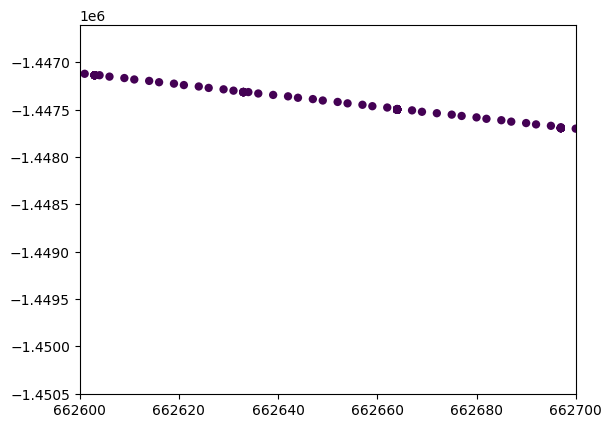

In [2]:
with segyio.open(file_path, ignore_geometry=True) as segyfile:
    segyfile.mmap()

    # Extract header word for all traces
    sourceX = segyfile.attributes(segyio.TraceField.SourceX)[:]

    # Scatter plot sources and receivers color-coded on their number
    plt.figure()
    sourceY = segyfile.attributes(segyio.TraceField.SourceY)[:]
    nsum = segyfile.attributes(segyio.TraceField.NSummedTraces)[:]
    plt.scatter(sourceX, sourceY, c=nsum, edgecolor='none')

    groupX = segyfile.attributes(segyio.TraceField.GroupX)[:]
    groupY = segyfile.attributes(segyio.TraceField.GroupY)[:]
    nstack = segyfile.attributes(segyio.TraceField.NStackedTraces)[:]
    plt.scatter(groupX, groupY, c=nstack, edgecolor='none')

    plt.xlim(662600,662700)

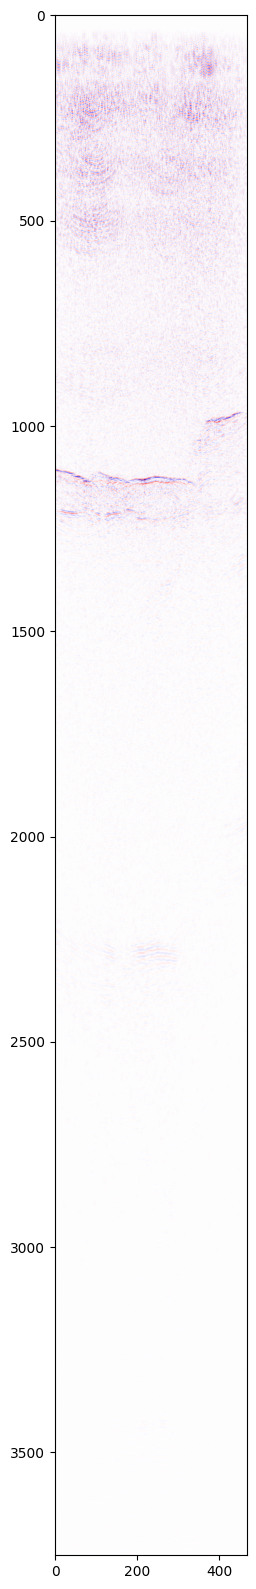

In [3]:
clip = 1e+2
vmin, vmax = -clip, clip

# Figure
figsize=(20, 20)
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=figsize, facecolor='w', edgecolor='k',
                       squeeze=False,
                       sharex=True)
axs = axs.ravel()
im = axs[0].imshow(f.trace.raw[:].T, cmap=plt.cm.seismic, vmin=vmin, vmax=vmax)

In [17]:
# Read and Plot individual seismic shots from KOPRI
# Zachary Katz
# 20 October 2025

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from obspy.io.segy.core import _read_segy
import os

file_path = './_data/KPDC_David_Seismic_2022/RAW/21X.sgy'
#file_path = './_data/KPDC_David_Seismic_2022/PSTM/D2SL2122_PSTM_Stack_Time_domain_static_aperture400_YY2.sgy'
seismogram = _read_segy(file_path, unpack_trace_headers=True)

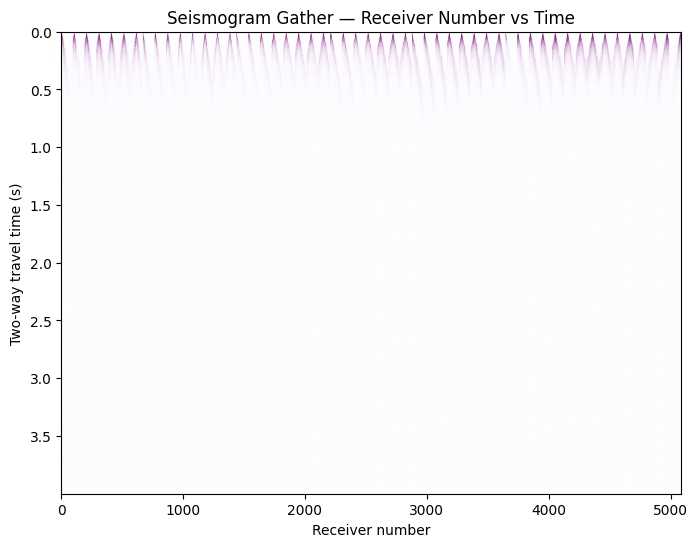

In [18]:
import numpy as np
import matplotlib.pyplot as plt

traces = seismogram.traces

# coordinate scalar from SEG-Y (sometimes negative means divide)
scalar = traces[0].stats.segy.trace_header.scalar_to_be_applied_to_all_coordinates
if scalar < 0:
    coord_scale = 1 / abs(scalar)
else:
    coord_scale = scalar

# source coordinate
src_x = traces[0].stats.segy.trace_header.source_coordinate_x * coord_scale
src_y = traces[0].stats.segy.trace_header.source_coordinate_y * coord_scale

# receiver coordinates
rec_x = np.array([tr.stats.segy.trace_header.group_coordinate_x for tr in traces]) * coord_scale
rec_y = np.array([tr.stats.segy.trace_header.group_coordinate_y for tr in traces]) * coord_scale

# ---- FIX HERE ----
# if coordinates look too small (e.g., offset < 500 m total), scale up by 1000
if np.max(np.abs(rec_x - src_x)) < 500:
    rec_x *= 1000
    rec_y *= 1000

# compute offset (m)
offset = np.sqrt((rec_x - src_x)**2 + (rec_y - src_y)**2)

# time axis
dt = traces[0].stats.delta  # in seconds
nt = traces[0].stats.npts
time = np.arange(nt) * dt

# plot wiggles or image
data = np.array([tr.data for tr in traces]).T

plt.figure(figsize=(8,6))
plt.imshow(data, aspect='auto', extent=[0, len(traces), time[-1], time[0]], cmap='seismic')
plt.xlabel("Receiver number")
plt.ylabel("Two-way travel time (s)")
plt.title("Seismogram Gather — Receiver Number vs Time")
plt.show()


In [6]:
print("Max offset (m):", np.max(offset))

Max offset (m): 4562561.066857078


In [19]:
for tr in seismogram.traces[:5]:
    hdr = tr.stats.segy.trace_header
    print(hdr)

AttribDict({'endian': '>', 'unpacked_header': None, 'trace_sequence_number_within_line': 1, 'trace_sequence_number_within_segy_file': 1, 'original_field_record_number': 2, 'trace_number_within_the_original_field_record': 1, 'energy_source_point_number': 2, 'ensemble_number': 6, 'trace_number_within_the_ensemble': 0, 'trace_identification_code': 1, 'number_of_vertically_summed_traces_yielding_this_trace': 1, 'number_of_horizontally_stacked_traces_yielding_this_trace': 1, 'data_use': 1, 'distance_from_center_of_the_source_point_to_the_center_of_the_receiver_group': -90, 'receiver_group_elevation': 2385, 'surface_elevation_at_source': 2370, 'source_depth_below_surface': 0, 'datum_elevation_at_receiver_group': 2385, 'datum_elevation_at_source': 2370, 'water_depth_at_source': 0, 'water_depth_at_group': 0, 'scalar_to_be_applied_to_all_elevations_and_depths': 1, 'scalar_to_be_applied_to_all_coordinates': 1, 'source_coordinate_x': 1215, 'source_coordinate_y': 1980, 'group_coordinate_x': 1125, 

In [20]:
USEC_TO_SEC = 1e-6
source_x = np.array([sgram.stats.segy.trace_header.source_coordinate_x for sgram in seismogram.traces])
source_y = np.array([sgram.stats.segy.trace_header.source_coordinate_y for sgram in seismogram.traces])
rec_x = np.array([sgram.stats.segy.trace_header.group_coordinate_x for sgram in seismogram.traces])
rec_y = np.array([sgram.stats.segy.trace_header.group_coordinate_y for sgram in seismogram.traces])
n = np.array([sgram.stats.segy.trace_header.number_of_samples_in_this_trace for sgram in seismogram.traces])
dt = np.array([sgram.stats.segy.trace_header.sample_interval_in_ms_for_this_trace * USEC_TO_SEC for sgram in seismogram.traces])

# Check same sample rate and number of samples for all traces
assert all(d == dt[0] for d in dt)
assert all(i == n[0] for i in n)

time = np.arange(n[0]) * dt[0]

In [21]:

offsets = []
for tr in seismogram.traces:
    hdr = tr.stats.segy.trace_header
    dx = hdr.group_coordinate_x - hdr.source_coordinate_x
    dy = hdr.group_coordinate_y - hdr.source_coordinate_y
    #offsets.append(tr.data[:10])
    offsets.append(np.sqrt(dx**2 + dy**2))
    
print(offsets[:])

[np.float64(90.0), np.float64(75.0), np.float64(60.0), np.float64(45.0), np.float64(30.0), np.float64(15.0), np.float64(0.0), np.float64(15.0), np.float64(30.0), np.float64(45.0), np.float64(60.0), np.float64(75.0), np.float64(90.0), np.float64(105.0), np.float64(120.0), np.float64(135.0), np.float64(150.0), np.float64(165.0), np.float64(180.0), np.float64(195.0), np.float64(210.0), np.float64(225.0), np.float64(240.0), np.float64(255.0), np.float64(270.0), np.float64(285.0), np.float64(300.0), np.float64(315.0), np.float64(330.0), np.float64(345.0), np.float64(360.0), np.float64(375.0), np.float64(390.0), np.float64(405.0), np.float64(420.0), np.float64(435.0), np.float64(450.0), np.float64(465.0), np.float64(480.0), np.float64(495.0), np.float64(510.0), np.float64(525.0), np.float64(540.0), np.float64(555.0), np.float64(570.0), np.float64(585.0), np.float64(600.0), np.float64(615.0), np.float64(630.0), np.float64(645.0), np.float64(660.0), np.float64(675.0), np.float64(690.0), np.flo

In [10]:
time

array([0.00000e+00, 2.50000e-04, 5.00000e-04, ..., 3.99925e+00,
       3.99950e+00, 3.99975e+00], shape=(16000,))

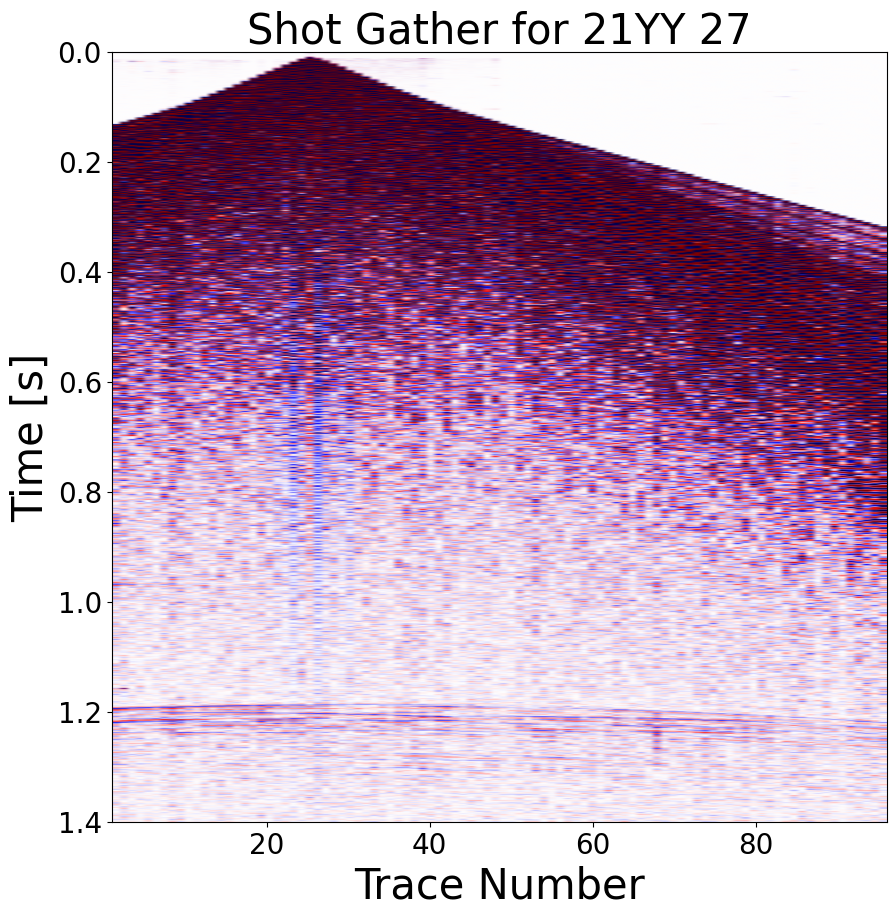

In [22]:
# Plot a single shot gather
shot_id = 27
n_traces = 96 #*10
start = (shot_id - 1) * n_traces
end = start + n_traces
data = np.column_stack([tr.data for tr in seismogram.traces[start:end]])
data /= np.abs(data).max()
rec_nums = np.arange(1, n_traces + 1)

fig, ax = plt.subplots(figsize=(10, 10))
extent = [rec_nums[0], rec_nums[-1], time[-1], time[0]]  # flip Y so time increases downward, divide by 2 to get two way trave time
im = ax.imshow(data, cmap="seismic", aspect="auto", extent=extent, vmin=-0.005, vmax=0.005)

ax.set_ylim(1.4, 0)
ax.set_xlabel("Trace Number",size=30)
ax.set_ylabel("Time [s]",size=30)
ax.set_title(f"Shot Gather for 21YY {shot_id}",size=30)
# Set xtick and ytick font size
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

In [141]:
for i, tr in enumerate(seismogram.traces[:5]):
    hdr = tr.stats.segy.trace_header
    print(i, hdr.group_coordinate_x, hdr.source_coordinate_x)

0 0 25800
1 0 25800
2 0 25800
3 0 25800
4 0 25800


Text(0.5, 1.0, 'D2SL2122_PSTM_Stack_Time_domain_static_aperture400_YY2.sgy')

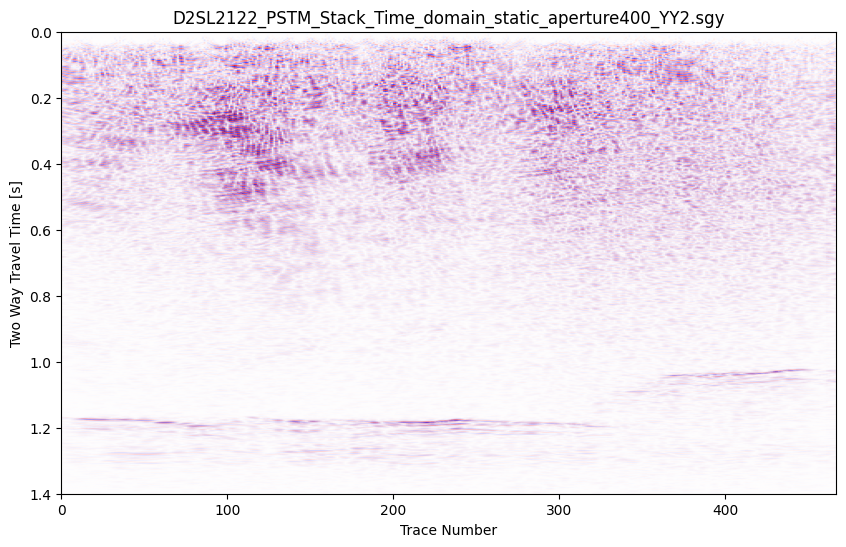

In [144]:
t = np.arange(n[0]) * dt[0]

arr = np.stack([sgram.data for sgram in seismogram.traces])
arr /= np.abs(arr).max()
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(
arr.T,
extent=[0, len(arr), max(t), min(t)],  # map array indices to coords & time
aspect="auto",
cmap="seismic",
vmin = -1,
vmax = 1,
)
ax.set_xlabel("Trace Number")
ax.set_ylabel("Two Way Travel Time [s]")
ax.set_ylim(1.4, 0)
ax.set_title("D2SL2122_PSTM_Stack_Time_domain_static_aperture400_YY2.sgy")

In [28]:
np.unique(arr)

array([-72.872955, -71.33273 , -68.95653 , ...,  48.265152,  51.559967,
        53.164078], shape=(1712121,), dtype=float32)